# Week 5: 머신러닝 데이터 전처리 및 회귀 모델 실습

## 1. 환경 설정
필요한 라이브러리를 로드합니다.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# 시각화 설정
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

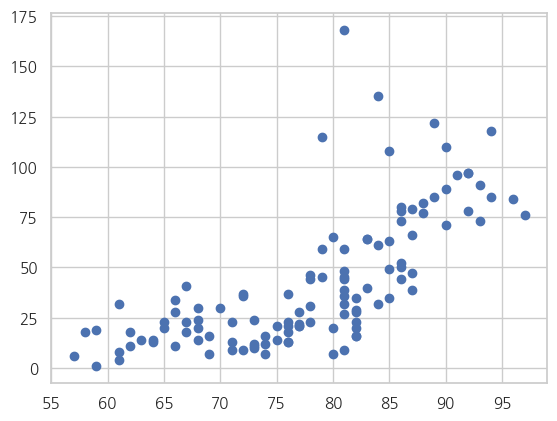

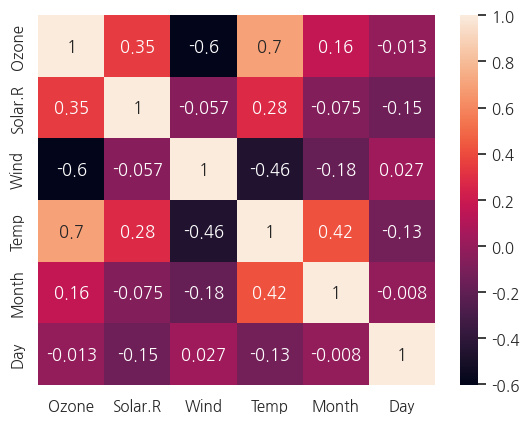

In [20]:
air = pd.read_csv('content/airquality.csv')

plt.scatter(air['Temp'], air['Ozone'])
plt.show()

sns.heatmap(air.corr(), annot=True)
plt.show()

In [ ]:
air = air.ffill()

if {'Month', 'Day'}.issubset(air.columns):
    air.drop(['Month', 'Day'], axis=1, inplace=True)

# target 확인
target = 'Ozone'

# 데이터 분리
X = air.drop(target, axis=1)
y = air[target]

[20. 35. 13. 82. 71.  7. 32. 63. 20. 37.]
[ 15.94183101  53.79749258  52.25622171  66.04921076  50.07228248
  18.40564765 -21.01533995  47.11870348  45.29927021  -1.62278276]
19.361471080646158


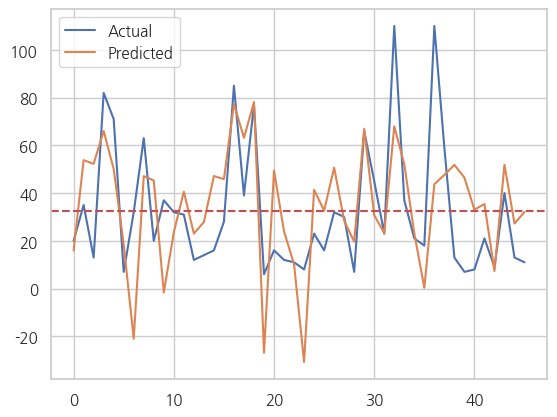

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.3,       # 30퍼센트
                                                    shuffle=True ,     # 섞은 후 나눈다.
                                                    random_state=200)

model = LinearRegression() # 회귀
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(y_test.values[:10])
print(y_pred[:10])

print(mean_absolute_error(y_test, y_pred))

mean_ozone = y_test.mean()

plt.plot(y_test.values, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.axhline(mean_ozone, color='r', linestyle='--')
plt.legend()
plt.show()